## METHODOLOGIE DE CONSTRUCTION DU JEU DE DONNEES

---

## Étapes de construction du jeu de données (Version finale)

| Étape | Description | Points de vigilance |
| :--- | :--- | :--- |
| **0. Définition de la date de référence** | Fixer la date du jour (ou la date de clôture du fichier). | Seule la production passée nous intéresse. |
| **1. Chargement des fichiers** | Import des données Excel. | Conversion explicite des dates en datetime. |
| **2. Filtrage des contrats historiques** | **Garder uniquement** les lignes de production où `dateeche < date_référence`. | **Exclut les contrats encore en cours** (évite le biais de censure). |
| **3. Nettoyage de la clé de jointure** | Reconstruire `police_clean` (codeinter + "-" + numepoli) dans les deux tables. | Standardisation des formats (suppression des espaces). |
| **4. Création d’un identifiant unique par garantie** | Construire `garantie_id` = `police_clean` + `codegara` + `dateeffe` + `dateeche`. | Permet d’identifier chaque garantie de manière unique et de gérer les avenants. |
| **5. Agrégation des Sinistres** | Calcul du coût net par sinistre, puis regroupement par contrat (`police_clean`). | Coût net = `montregl` + `sap_sysdate` - `montreco` - `rae_sinistre`. On compte aussi les sinistres corporels et les dossiers ouverts. |
| **6. Jointure** | Rattacher les indicateurs de sinistralité (agrégés par contrat) à chaque garantie via `police_clean` (Left Join). | Une garantie hérite des sinistres de son contrat. Les valeurs NaN sont remplacées par 0. |
| **7. Feature Engineering** | Création de variables dérivées au niveau garantie. | Âge du véhicule à la date d'effet de la garantie (`dateeffe`). Durée de la garantie (`dateeche` - `dateeffe`). |
| **8. Définition de la variable cible** | La cible est la prime de la garantie : `primtota_q`. | On filtre les primes négatives (remboursements). |
| **9. Nettoyage final & Export** | Sélection des colonnes pertinentes et sauvegarde en CSV. | Gestion des valeurs aberrantes et des divisions par zéro. |

In [1]:
# Librairies
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
import os

In [2]:
# Fonction pour retirer les warnings
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [3]:
# Etape 0 : Date de référence pour le filtrage historique
REFERENCE_DATE = datetime.now()
print(f"Date de référence (fin de l'historique): {REFERENCE_DATE.strftime('%Y-%m-%d')}")

Date de référence (fin de l'historique): 2026-09-21


In [4]:
# Etape 1 : Chargement des données
chemin_notebooks = os.getcwd()
chemin_projet= os.path.dirname(chemin_notebooks)
chemin_donnees = os.path.join(chemin_projet, "Data")

# Données de production
chemin_donnees_prod = os.path.join(chemin_donnees, "DonneesDeBase", "prod de base.xlsx")
print('chargement des données de production...')
prod = pd.read_excel(chemin_donnees_prod, sheet_name = "Feuil1")

# Données de sinistres
chemin_donnees_sin = os.path.join(chemin_donnees, "DonneesDeBase", "Sinistres_2023_2025_v2.xlsx")
print('chargement des données de sinistre...')
sin = pd.read_excel(chemin_donnees_sin)

# Données des sinistres à payer (SAP)
chemin_donnees_sap = os.path.join(chemin_donnees, "DonneesDeBase", "Sap_2023_2025.xlsx")
print('chargement des données de sap...')
sap = pd.read_excel(chemin_donnees_sap)


print(f"Nombre de lignes dans le fichier de production : {len(prod)}")
print(f"Nombre de lignes dans le fichier de sinistres : {len(sin)}")
sin.head()

chargement des données de production...


chargement des données de sinistre...
chargement des données de sap...
Nombre de lignes dans le fichier de production : 131360
Nombre de lignes dans le fichier de sinistres : 1376


,CODEINTE,RAISOCIN,EXERSINI,NUMESINI,INTEPOLI,NUMEPOLI,POLICE,CODEASSU,ASSURÉ,NATURE,...,LIBEGARA,CATERISQ,SORT,DATESORT,MONTHONO,MONTINDE,MONTREGL,RECOHONO,RECOPRIN,MONTRECO
0,1000,"Bureau Direct Siege, Douala",2022,100021,1000,1010009641,1000-1010009641,-10000228464,NJONGUO TIALEFACK,Matériel,...,DOMMAGES / Damages,1010,Cloturé,2022-10-27 16:43:59,54625,0,54625,0,0,0
1,1000,"Bureau Direct Siege, Douala",2022,100021,1000,1010009641,1000-1010009641,-10000228464,NJONGUO TIALEFACK,Matériel,...,DOMMAGES / Damages,1010,Cloturé,2022-10-27 16:43:59,0,502896,502896,0,0,0
2,1000,"Bureau Direct Siege, Douala",2022,100271,1000,1010006368,1000-1010006368,-99990071870,ZENITHE INSURANCE,Matériel,...,DOMMAGES / Damages,1010,Cloturé,2025-12-02 00:00:00,3000,0,3000,0,0,0
3,1000,"Bureau Direct Siege, Douala",2022,100271,1000,1010006368,1000-1010006368,-99990071870,ZENITHE INSURANCE,Matériel,...,DOMMAGES / Damages,1010,Cloturé,2025-12-02 00:00:00,0,1929753,1929753,0,0,0
4,1000,"Bureau Direct Siege, Douala",2022,100271,1000,1010006368,1000-1010006368,-99990071870,ZENITHE INSURANCE,Matériel,...,DOMMAGES / Damages,1010,Cloturé,2025-12-02 00:00:00,54625,0,54625,0,0,0


In [5]:
# Mettre en minuscule les noms des colonnes pour les données de sinistre
prod.columns = prod.columns.str.strip().str.lower()
sin.columns = sin.columns.str.strip().str.lower()
sap.columns = sap.columns.str.strip().str.lower()

display(prod.columns)
display(sin.columns)
display(sap.columns)

Index(['typeinter', 'codeinte', 'bureau', 'numepoli', 'police', 'numeimma',
       'chassis', 'marque', 'modèle', 'puissance', 'places', 'modèle_1',
       'numepermis', 'typepermis', 'date_mise_en_circ', 'valeur_neuve',
       'valeur_venale', 'ville', 'numeaven', 'avevant', 'coderisq', 'codegara',
       'libegara', 'codebran', 'libebran', 'codecate_q', 'categorie_mère',
       'codecate', 'categorie', 'dateeffe', 'dateeche', 'datemis', 'primnett',
       'accequit', 'primtota_q', 'tauxpart', 'prinetco', 'chifaffa', 'dta',
       'commappo', 'capital'],
      dtype='object')

Index(['codeinte', 'raisocin', 'exersini', 'numesini', 'intepoli', 'numepoli',
       'police', 'codeassu', 'assuré', 'nature', 'numeimma', 'numechasis',
       'mise_en_circ', 'dateeffet', 'echeance', 'datesurv', 'datedecl',
       'dateregl', 'lieninte', 'codecate', 'codebran', 'libebran', 'libecate',
       'refeinte', 'codegara', 'libegara', 'caterisq', 'sort', 'datesort',
       'monthono', 'montinde', 'montregl', 'recohono', 'recoprin', 'montreco'],
      dtype='object')

Index(['codeinte', 'raisocin', 'intesini', 'exersini', 'numesini', 'refeinte',
       'intepoli', 'numepoli', 'police', 'numeaven', 'codeassu', 'assure',
       'datesurv', 'datedecl', 'codecate', 'libecate', 'codebran', 'libebran',
       'natusini', 'lieninte', 'codegara', 'caterisq', 'libegara', 'sort',
       'datesort', 'partcoas', 'dateeffet', 'echeance', 'capital', 'monteval',
       'sap_debut', 'sap 31/12/2025'],
      dtype='object')

In [6]:
# Etape 2 : Conversion des dates & Filtrage des données historiques
prod['dateeche'] = pd.to_datetime(prod['dateeche'], errors='coerce')
prod['dateeffe'] = pd.to_datetime(prod['dateeffe'], errors='coerce')

# Règle : nous ne gardons que les lignes dont la date d'échéance est passée.
prod_historique = prod[prod['dateeche'] < REFERENCE_DATE].copy()
print(f"Nombre de lignes (garanties) dont la date d'échéance est passée : {len(prod_historique)}")

Nombre de lignes (garanties) dont la date d'échéance est passée : 131360


In [7]:
# Etape 3 : Standardisation de la clé de jointure
prod_historique['police_clean'] = (prod_historique['codeinte'].astype(str).str.strip() + "-" + 
                                   prod_historique['numepoli'].astype(str).str.strip())

sin['police_clean'] = (sin['intepoli'].astype(str).str.strip() + "-" +
    sin['numepoli'].astype(str).str.strip())

sap['police_clean'] = (sap['intepoli'].astype(str).str.strip() + "-" +
                       sap['numepoli'].astype(str).str.strip())

In [8]:
prod_historique.shape, sin.shape, sap.shape

((131360, 42), (1376, 36), (1929, 33))

In [9]:
# Etape 4 : Création d'un identifiant unique pour chaque garantie

# Une garantie est identifiée par: police + codegara + dateeffe + dateeche
# Cela permet de distinguer les différents avenants d'une meme garantie
prod_historique['garantie_id'] = (
    prod_historique['police_clean'] + "_" +
    prod_historique['dateeffe'].dt.strftime('%Y%m%d') + "_" +
    prod_historique['dateeche'].dt.strftime('%Y%m%d')
)

In [10]:
sin.columns.sort_values()

Index(['assuré', 'caterisq', 'codeassu', 'codebran', 'codecate', 'codegara',
       'codeinte', 'datedecl', 'dateeffet', 'dateregl', 'datesort', 'datesurv',
       'echeance', 'exersini', 'intepoli', 'libebran', 'libecate', 'libegara',
       'lieninte', 'mise_en_circ', 'monthono', 'montinde', 'montreco',
       'montregl', 'nature', 'numechasis', 'numeimma', 'numepoli', 'numesini',
       'police', 'police_clean', 'raisocin', 'recohono', 'recoprin',
       'refeinte', 'sort'],
      dtype='object')

In [11]:
# Etape 5 : Jointure entre sinistres et sap pour compléter le montant des sinistres à payer
display(sin.shape, sap.shape)

# aggrégation des sap par police 
sap_ = sap.groupby('police_clean')[['sap 31/12/2025']].sum()
sin_final = pd.merge(sin, sap_, on='police_clean', how = 'left')
display(sin_final.shape)

(1376, 36)

(1929, 33)

(1376, 37)

In [12]:
# Etape 6 : Aggrégation des sinistres

# calcul du cout net d'un sinistre
sin_final['cout_net_sinistre'] = (
    sin_final['montregl'].fillna(0)
    + sin_final['sap 31/12/2025'].fillna(0)
    - sin_final['montreco'].fillna(0)
    #- sin['rae_sinistre'].fillna(0)
)

sin_agg = sin_final.groupby('police_clean').agg({
    'numesini': 'count',
    'cout_net_sinistre': 'sum',
    #'codnatsi': lambda x: (x.isin(['C', 'D']).sum()), # Compte des corporels/mixtes
    'datesurv': 'max',
    'sort': lambda x: (x == 'Ouvert').sum() # compte des sinistres encore ouverts
})

sin_agg.rename(columns={
    'numesini': 'nb_sinistres',
    'cout_net_sinistre': 'cout_total_sinistres',
    #'codnatsi': 'nb_sinistres_corporels',
    'datesurv': 'date_dernier_sinistre',
    'sort' : 'nb_sinistres_ouverts'
}, inplace=True)
print(f"Contrats avec sinistres : {sin_agg.shape[0]}")

Contrats avec sinistres : 474


In [13]:
# Etape 7 : Jointure finale (left join)
print(f"Dimensions avant jointure: {prod_historique.shape}")
df_final = pd.merge(prod_historique, sin_agg, on='police_clean', how = 'left')
print(f"Dimensions après jointure: {df_final.shape}")

# Remplissage des NaN par 0 pour les contrats sans sinistres
cols_sinistres = ['nb_sinistres', 'cout_total_sinistres', 'nb_sinistres_ouverts']
df_final[cols_sinistres] = df_final[cols_sinistres].fillna(0)
df_final.head()

Dimensions avant jointure: (131360, 43)
Dimensions après jointure: (131360, 47)


,typeinter,codeinte,bureau,numepoli,police,numeimma,chassis,marque,modèle,puissance,...,chifaffa,dta,commappo,capital,police_clean,garantie_id,nb_sinistres,cout_total_sinistres,date_dernier_sinistre,nb_sinistres_ouverts
0,Bureau Direct,1004,BAMENDA REGIONAL OFFICE,1010003466,1004-1010003466,NW 092 AZ,JSAJTD54V00110055,TOYOTA,HG20V,11.0,...,0,0.0,0,0.0,1004-1010003466,1004-1010003466_20230111_20230713,0.0,0.0,NaT,0.0
1,Bureau Direct,1004,BAMENDA REGIONAL OFFICE,1010003466,1004-1010003466,NW 092 AZ,JSAJTD54V00110055,TOYOTA,HG20V,11.0,...,1017,1703.0,51,0.0,1004-1010003466,1004-1010003466_20230111_20230713,0.0,0.0,NaT,0.0
2,Agent Général,6127,EMERGENCE,1500000493,6127-1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,...,371,0.0,77,0.0,6127-1500000493,6127-1500000493_20230214_20240213,0.0,0.0,NaT,0.0
3,Agent Général,6127,EMERGENCE,1500000493,6127-1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,...,3017,0.0,633,0.0,6127-1500000493,6127-1500000493_20230214_20240213,0.0,0.0,NaT,0.0
4,Agent Général,6003,AG NOUTONG,1010002803,6003-1010002803,CH 213068,213068,LEXUS NX,BO46,9.0,...,0,0.0,0,0.0,6003-1010002803,6003-1010002803_20230217_20240216,0.0,0.0,NaT,0.0


In [14]:
display(df_final[df_final['cout_total_sinistres']>0].shape)
display(df_final.shape)

(20695, 47)

(131360, 47)

In [15]:
# Etape 8 : Création de variables dérivées

# Age du véhicule à la souscription (dernier avenant) 
df_final['date_mise_en_circ'] = pd.to_datetime(df_final['date_mise_en_circ'], errors='coerce')
df_final['dateeffe'] = pd.to_datetime(df_final['dateeffe'], errors='coerce')
df_final['age_vehicule_annees'] = (df_final['dateeffe'] - df_final['date_mise_en_circ']).dt.days / 365.25 # Convertir en années

# durée de la garantie (en jours)
df_final['duree_garantie_jours'] = (df_final['dateeche'] - df_final['dateeffe']).dt.days

In [16]:
df_final.columns.sort_values()

Index(['accequit', 'age_vehicule_annees', 'avevant', 'bureau', 'capital',
       'categorie', 'categorie_mère', 'chassis', 'chifaffa', 'codebran',
       'codecate', 'codecate_q', 'codegara', 'codeinte', 'coderisq',
       'commappo', 'cout_total_sinistres', 'date_dernier_sinistre',
       'date_mise_en_circ', 'dateeche', 'dateeffe', 'datemis', 'dta',
       'duree_garantie_jours', 'garantie_id', 'libebran', 'libegara', 'marque',
       'modèle', 'modèle_1', 'nb_sinistres', 'nb_sinistres_ouverts',
       'numeaven', 'numeimma', 'numepermis', 'numepoli', 'places', 'police',
       'police_clean', 'primnett', 'primtota_q', 'prinetco', 'puissance',
       'tauxpart', 'typeinter', 'typepermis', 'valeur_neuve', 'valeur_venale',
       'ville'],
      dtype='object')

In [17]:
df_final.columns

Index(['typeinter', 'codeinte', 'bureau', 'numepoli', 'police', 'numeimma',
       'chassis', 'marque', 'modèle', 'puissance', 'places', 'modèle_1',
       'numepermis', 'typepermis', 'date_mise_en_circ', 'valeur_neuve',
       'valeur_venale', 'ville', 'numeaven', 'avevant', 'coderisq', 'codegara',
       'libegara', 'codebran', 'libebran', 'codecate_q', 'categorie_mère',
       'codecate', 'categorie', 'dateeffe', 'dateeche', 'datemis', 'primnett',
       'accequit', 'primtota_q', 'tauxpart', 'prinetco', 'chifaffa', 'dta',
       'commappo', 'capital', 'police_clean', 'garantie_id', 'nb_sinistres',
       'cout_total_sinistres', 'date_dernier_sinistre', 'nb_sinistres_ouverts',
       'age_vehicule_annees', 'duree_garantie_jours'],
      dtype='object')

In [18]:
# Etape 9 : Creation de la variable cible

# Notre cible est la prime totale de la garantie (primtota_q)
# On filtre les primes négatives (remboursements) car on veut prédire des primes positives
df_final = df_final[df_final['primnett'] > 0].copy()

# Là où les sinistres sont supérieures aux primes, on récupère les sinistres
df_final['y_cible'] = np.where(
    df_final['primnett'] > df_final['cout_total_sinistres'],
    df_final['primnett'],
    df_final['cout_total_sinistres']
)

In [19]:
display(len(df_final.sort_index(axis=1).columns))
display(df_final.sort_index(axis=1).columns)

50

Index(['accequit', 'age_vehicule_annees', 'avevant', 'bureau', 'capital',
       'categorie', 'categorie_mère', 'chassis', 'chifaffa', 'codebran',
       'codecate', 'codecate_q', 'codegara', 'codeinte', 'coderisq',
       'commappo', 'cout_total_sinistres', 'date_dernier_sinistre',
       'date_mise_en_circ', 'dateeche', 'dateeffe', 'datemis', 'dta',
       'duree_garantie_jours', 'garantie_id', 'libebran', 'libegara', 'marque',
       'modèle', 'modèle_1', 'nb_sinistres', 'nb_sinistres_ouverts',
       'numeaven', 'numeimma', 'numepermis', 'numepoli', 'places', 'police',
       'police_clean', 'primnett', 'primtota_q', 'prinetco', 'puissance',
       'tauxpart', 'typeinter', 'typepermis', 'valeur_neuve', 'valeur_venale',
       'ville', 'y_cible'],
      dtype='object')

In [20]:
# Colonnes à supprimer pour l'analyse
colonnes_a_supprimer = ["nb_sinistres", "cout_total_sinistres", "date_dernier_sinistre",
                        "nb_sinistres_ouverts", 'avevant', 'modèle_1', 'numeaven', 'police_clean', 'police', 'primnett', 'primtota_q',
                        'prinetco']

df_final_vf = df_final.drop(columns=colonnes_a_supprimer)

In [21]:
df_final_vf.head(3)

,typeinter,codeinte,bureau,numepoli,numeimma,chassis,marque,modèle,puissance,places,...,accequit,tauxpart,chifaffa,dta,commappo,capital,garantie_id,age_vehicule_annees,duree_garantie_jours,y_cible
1,Bureau Direct,1004,BAMENDA REGIONAL OFFICE,1010003466,NW 092 AZ,JSAJTD54V00110055,TOYOTA,HG20V,11.0,5.0,...,0,NaN,1017,1703.0,51,0.0,1004-1010003466_20230111_20230713,17.026694,182,1017.0
2,Agent Général,6127,EMERGENCE,1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,2.0,...,63,NaN,371,0.0,77,0.0,6127-1500000493_20230214_20240213,0.131417,363,308.0
3,Agent Général,6127,EMERGENCE,1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,2.0,...,517,NaN,3017,0.0,633,0.0,6127-1500000493_20230214_20240213,0.131417,363,2500.0


In [22]:
longues_colonnes = ['marque', 'modèle', 'ville', 'libegara', 'categorie_mère']
for col in longues_colonnes:
    print(f"=============== N premières modalités de la colonne {col} ===================")
    display(df_final_vf[col].unique()[:40])
    print()

=============== N premières modalités de la colonne marque ===================


array(['TOYOTA', 'ROYAL', 'LEXUS NX', 'JAC', 'HYUNDAI', 'HOWO', 'ISUZU',
       'RVI', 'SUZUKI', 'MERCEDES', 'LAND ROVER', 'RANGE ROVER', 'MAZDA',
       'FORD', 'Toutes Marques', 'MITSUBISHI', 'ENGINE', 'ENGIN', 'KIA',
       'TOYOTA COROLLA', 'OPEL', '.TOYOTA', 'SANILY', 'TVS',
       'MITSUBISHI OUTLANDER', 'PEUGEOT', 'HONDA', 'TOYOTA TERCEL', 'MAN',
       'VOLVO', 'LIFAN', 'NISSAN', 'SANILI', 'BLI', 'FIAT', 'VOLKSWAGEN',
       'YARIS VVT-1', 'BOXER', 'HAOJUE', 'HYUNDIA'], dtype=object)


=============== N premières modalités de la colonne modèle ===================


array(['HG20V', 'CARGO', 'BO46', 'HH20V', 'BAO2E3', 'KW20E', 'GH22B2',
       'HFC 4251 KR1', 'KW223', '..', 'Z134A8', 'DH4AE', '10 ROUES',
       '12ROUES', '10ROUES', 'KU4EE1', 'NPR71H', 'EOEE90', '64ATK', '-',
       '64ABND', 'KR32E6', 'SANFE', 'DB52T', 'AE114', 'EE90', '64ABN0',
       '3340/4500', 'RUNZ KZ28E', 'LNABA7', 'GRAND VITARA', '.', '64ZEB1',
       'UXXGAJ', 'COROLLA VERS', 'SENKE', 'ML350', 'KT2237', 'BD32V1',
       'BU88'], dtype=object)


=============== N premières modalités de la colonne ville ===================


array(['BAMENDA', 'MAROUA', 'DOUALA', 'EBOLOWA', 'YAOUNDE', 'LIMBÉ',
       'NDOP', 'BAFOUSSAM', 'BUÉA', 'GAROUA', 'BALENG', 'NJOMBE-PENJA',
       'SANTA', 'BAFUT', 'NDJAMENA (TCHAD)', 'KRIBI', 'KAÉLÉ', 'BELO',
       'NKAMBÉ', 'KUMBA', 'WUM', 'KOUSSÉRI', 'DSCHANG', 'BERTOUA',
       'NGAOUNDÉRÉ', 'EKONDO-TITI', 'ESSEKA', 'MBENGWI', 'KUMBO',
       'MOKOLO', 'BATIBO', 'BATOURI', 'MUNDEMBA', 'BATCHAM', 'MAMFÉ',
       'FUNDONG', 'BAFIA', 'FOUMBAN', 'GUIDER', 'TIKO'], dtype=object)


=============== N premières modalités de la colonne libegara ===================


array(['DEFENSE- RECOURS / RECOURSE',
       'INDIVIDUELLE ACCIDENTS CHAUFFEURS / Drivers Acc.',
       'INDIV. PERSONNES TRANSPORTEES / TRANSPORTED PERS.',
       'DOMMAGES / Damages', 'INCENDIE / FIRE',
       'VOL TOTAL + VOL PARTIEL + VOL BRAQUAGE', 'VOL TOTAL / THEFT',
       'VOL TOTAL + VOL PARTIEL/ THEFT & PARTIAL THEFT',
       'AVANCE SUR RECOURS', 'ASSISTANCE à reparation/sinistre/an',
       'REMORQUAGE/SINISTRE/AN', 'BRIS DE GLACE / BROKEN GLASS',
       'VOL TOTAL + VOL PARTIEL + VOL BRAQUAGE_TT. TERRAIN',
       'BRIS DE GLACE + BLOC FEUX / BROKEN GLASS-HEAD LAMP',
       'Assistance Routière', 'RECOURS TIERS INCENDIE',
       'DOMMAGES 1ER RISQUE / Comprehensive', 'TRACKING',
       'TIERCE COLLISION / Third Party Collision'], dtype=object)


=============== N premières modalités de la colonne categorie_mère ===================


array(['TOURISME - VEHICULE PERSONNEL / PERSONAL CAR',
       '2 A 3 ROUES - PERSONNEL / PERSONAL BYKES', 'FLOTTE / FLEET',
       'UTILITAIRES-CHARGE UTILE>3,5T / UTILITY >3.5 T',
       'TRANSPORT PRIVE DE MARCHANDISES / UTILITY < 3.5 T',
       'ENGINS MOBILES DE CHANTIER/ MOBILE SITE ENGINES',
       'AUTO-ECOLE  / DRIVING SCHOOL',
       'TAXIS DE VILLE (4A) / TOWNSHIP TAXIS',
       'TPV - CARS AUTOBUS ET BUS / TRANSPORT BUSES',
       'AMBULANCES - CORBILLARDS - FOURGONS FUNEBRES',
       'TRANSPORT DE PERSONNEL ET/OU DES ELEVES /STAFF BUSES',
       'AUTRE FLOTTE / MIXED FLEET', 'GARAGISTES (6A) / MOTOR REPAIRS',
       'AUTO LOCATION / CAR RENTALS',
       'CAMION DE VIDANGE / SANITARY TRUCKS'], dtype=object)

In [23]:
# Chemins d'acces
notebooks_path = os.getcwd()
project_path = os.path.dirname(notebooks_path)

modalites_marque_path = os.path.join(project_path, 'Data', 'DonneesPreparees', 'modalités_marque.txt')
modalites_modele_path = os.path.join(project_path, 'Data', 'DonneesPreparees', 'modalités_modele.txt')

In [24]:
# Ecriture dans un fichier txt des modalités de la colonne 'marque'
with open(modalites_marque_path, 'w') as file:
    for modalite in df_final_vf['marque'].unique().tolist():
        file.write(f"{modalite}\n")

# Ecriture dans un fichier txt des modalités de la colonne 'modele'
with open(modalites_modele_path, 'w') as file:
    for modalite in df_final_vf['modèle'].unique().tolist():
        file.write(f"{modalite}\n")

##### Nettoyage des colonnes `marque` et `modele`

---

##### Approche : Modèle = Marque + Modèle
Voici la stratégie:

1. Nettoyer la colonne marque (avec LLM) -> obtenir marque_normalisee.

2. Utiliser cette marque normalisée pour contextualiser le modèle.

3. Groupement et encodage des modèles PAR MARQUE.

In [25]:
import json 

# Import du json traité par le LLM
mapping_json_path = os.path.join(project_path, "Data", "DonneesPreparees", "mapping_marques.json")

with open(mapping_json_path, 'r') as file:
    mapping = json.load(file)

In [26]:
mapping

{'TOYOTA': {'marque_normalisee': 'TOYOTA',
  'segment': 'GENERALISTE',
  'type_vehicule': 'BERLINE'},
 'ROYAL': {'marque_normalisee': 'ROYAL',
  'segment': 'DEUX_ROUES',
  'type_vehicule': 'MOTO'},
 'LEXUS NX': {'marque_normalisee': 'LEXUS',
  'segment': 'PREMIUM',
  'type_vehicule': 'SUV'},
 'JAC': {'marque_normalisee': 'JAC',
  'segment': 'GENERALISTE',
  'type_vehicule': 'AUTRE'},
 'HYUNDAI': {'marque_normalisee': 'HYUNDAI',
  'segment': 'GENERALISTE',
  'type_vehicule': 'BERLINE'},
 'HOWO': {'marque_normalisee': 'HOWO',
  'segment': 'POIDS_LOURD',
  'type_vehicule': 'POIDS_LOURD'},
 'ISUZU': {'marque_normalisee': 'ISUZU',
  'segment': 'GENERALISTE',
  'type_vehicule': 'PICKUP'},
 'RVI': {'marque_normalisee': 'RVI',
  'segment': 'POIDS_LOURD',
  'type_vehicule': 'POIDS_LOURD'},
 'SUZUKI': {'marque_normalisee': 'SUZUKI',
  'segment': 'GENERALISTE',
  'type_vehicule': 'BERLINE'},
 'MERCEDES': {'marque_normalisee': 'MERCEDES',
  'segment': 'PREMIUM',
  'type_vehicule': 'BERLINE'},
 'LA

In [27]:
# Application du mapping pour avoir la marque normalisée et toutes les autres colonnes qui en découlent
df_final_vf['marque_normalisee'] = df_final_vf['marque'].map(lambda x: mapping.get(x, {}).get('marque_normalisee', 'AUTRE'))
df_final_vf['segment'] = df_final_vf['marque'].map(lambda x: mapping.get(x, {}).get('segment', 'AUTRE'))
df_final_vf['type_vehicule'] = df_final_vf['marque'].map(lambda x: mapping.get(x, {}).get('type_vehicule', 'AUTRE'))

In [28]:
df_final_vf.head(3)

,typeinter,codeinte,bureau,numepoli,numeimma,chassis,marque,modèle,puissance,places,...,dta,commappo,capital,garantie_id,age_vehicule_annees,duree_garantie_jours,y_cible,marque_normalisee,segment,type_vehicule
1,Bureau Direct,1004,BAMENDA REGIONAL OFFICE,1010003466,NW 092 AZ,JSAJTD54V00110055,TOYOTA,HG20V,11.0,5.0,...,1703.0,51,0.0,1004-1010003466_20230111_20230713,17.026694,182,1017.0,TOYOTA,GENERALISTE,BERLINE
2,Agent Général,6127,EMERGENCE,1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,2.0,...,0.0,77,0.0,6127-1500000493_20230214_20240213,0.131417,363,308.0,ROYAL,DEUX_ROUES,MOTO
3,Agent Général,6127,EMERGENCE,1500000493,CH 002464,CH 002464,ROYAL,CARGO,1.0,2.0,...,0.0,633,0.0,6127-1500000493_20230214_20240213,0.131417,363,2500.0,ROYAL,DEUX_ROUES,MOTO


In [29]:
# Nettoyage des modèles 
import re

def nettoyer_modele(modele):
    " Nettoie une chaine pour le modèle du véhicule"
    if pd.isna(modele):
        return 'INCONNU'
    modele = str(modele).strip().upper()
    # On garde les lettres, les chiffres, les tirets et espaces
    modele = re.sub(r'[^A-Z0-9\-]', ' ', modele)
    # Supprime les espace 
    modele = ' '.join(modele.split()) 

    if modele == '' or modele in ['.', '..', '...', '-', 'INCONNU']:
        return 'INCONNU'
    return modele

# Application sur le dataset
df_final_vf['modele_propre'] = df_final_vf['modèle'].apply(nettoyer_modele)

# Vérification
display(df_final_vf[['modèle', 'modele_propre']].sample(10))

,modèle,modele_propre
5320,B236,B236
6901,701,701
95303,AXXWPD,AXXWPD
11997,RAV4,RAV4
118832,64ABK1,64ABK1
61912,PICK UP,PICK UP
31923,203153600,203153600
92175,RAV4,RAV4
37536,.,INCONNU
112198,TRACTEUR,TRACTEUR


In [30]:
# Choisir le nombre de modèles les plus fréquents à garder par marque
TOP_K = 5

# Une seule passe pour extraire les top modèles par marque
top_modeles_par_marque = {}
for marque in df_final_vf['marque_normalisee'].unique():
    top = df_final_vf[df_final_vf['marque_normalisee'] == marque]['modele_propre'].value_counts().head(TOP_K).index
    top_modeles_par_marque[marque] = set(top)  # set pour test O(1)

# Application vectorisée via une fonction lambda rapide
df_final_vf['modele_groupe'] = df_final_vf.apply(
    lambda row: row['modele_propre'] 
    if row['modele_propre'] in top_modeles_par_marque.get(row['marque_normalisee'], set())
    else f"AUTRE_{row['marque_normalisee']}",
    axis=1
)

# Voir les premières lignes
display(df_final_vf[['marque_normalisee', 'modele_propre', 'modele_groupe']].head(20))

,marque_normalisee,modele_propre,modele_groupe
1,TOYOTA,HG20V,AUTRE_TOYOTA
2,ROYAL,CARGO,AUTRE_ROYAL
3,ROYAL,CARGO,AUTRE_ROYAL
5,LEXUS,BO46,AUTRE_LEXUS
6,LEXUS,BO46,AUTRE_LEXUS
8,TOYOTA,HH20V,AUTRE_TOYOTA
10,TOYOTA,BAO2E3,AUTRE_TOYOTA
11,TOYOTA,BAO2E3,AUTRE_TOYOTA
13,TOYOTA,KW20E,AUTRE_TOYOTA
15,TOYOTA,GH22B2,AUTRE_TOYOTA


In [31]:
# Suppression des colonnes sales de départ
df_final_vf = df_final_vf.drop(columns=["marque", "modèle", "modele_propre"]).rename(columns={
    "marque_normalisee" : "marque",
    "modele_groupe": "modèle"
})
df_final_vf = df_final_vf.sort_index(axis=1)
df_final_vf.head(3)

,accequit,age_vehicule_annees,bureau,capital,categorie,categorie_mère,chassis,chifaffa,codebran,codecate,...,puissance,segment,tauxpart,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,ville,y_cible
1,0,17.026694,BAMENDA REGIONAL OFFICE,0.0,TOURISME - VEHICULE PERSONNEL / PERSONAL CAR,TOURISME - VEHICULE PERSONNEL / PERSONAL CAR,JSAJTD54V00110055,1017,1,1010,...,11.0,GENERALISTE,NaN,BERLINE,Bureau Direct,B,NaN,NaN,BAMENDA,1017.0
2,63,0.131417,EMERGENCE,0.0,2 A 3 ROUES - PERSONNEL / PERSONAL BYKES,2 A 3 ROUES - PERSONNEL / PERSONAL BYKES,CH 002464,371,1,1050,...,1.0,DEUX_ROUES,NaN,MOTO,Agent Général,A,NaN,NaN,MAROUA,308.0
3,517,0.131417,EMERGENCE,0.0,2 A 3 ROUES - PERSONNEL / PERSONAL BYKES,2 A 3 ROUES - PERSONNEL / PERSONAL BYKES,CH 002464,3017,1,1050,...,1.0,DEUX_ROUES,NaN,MOTO,Agent Général,A,NaN,NaN,MAROUA,2500.0


In [32]:
# Les categories mères les plus représentées

mapping_categories = {
    "TOURISME - VEHICULE PERSONNEL / PERSONAL CAR": "Tourisme (VP)",
    "FLOTTE / FLEET": "Flotte pro",
    "TAXIS DE VILLE (4A) / TOWNSHIP TAXIS": "Taxis",
    "TRANSPORT PRIVE DE MARCHANDISES / UTILITY < 3.5 T": "Utilitaire < 3.5T",
    "2 A 3 ROUES - PERSONNEL / PERSONAL BYKES": "2/3 Roues",
    "TPV - CARS AUTOBUS ET BUS / TRANSPORT BUSES": "Autocars / Bus",
    "UTILITAIRES-CHARGE UTILE>3,5T / UTILITY >3.5 T": "Utilitaire > 3.5T",
    "AUTO-ECOLE  / DRIVING SCHOOL": "Auto-école",
    "ENGINS MOBILES DE CHANTIER/ MOBILE SITE ENGINES": "Engins chantier",
    "AMBULANCES - CORBILLARDS - FOURGONS FUNEBRES": "Ambulances / Funéraire",
    "TRANSPORT DE PERSONNEL ET/OU DES ELEVES /STAFF BUSES": "Navette (personnel/élèves)",
    "AUTRE FLOTTE / MIXED FLEET": "Autre flotte",
    "GARAGISTES (6A) / MOTOR REPAIRS": "Garagiste",
    "CAMION DE VIDANGE / SANITARY TRUCKS": "Camion vidange",
    "AUTO LOCATION / CAR RENTALS": "Location auto"
}
df_final_vf['categorie_mère'] = df_final_vf['categorie_mère'].map(mapping_categories)

display(df_final_vf['categorie_mère'].value_counts())

categorie_mère
Tourisme (VP)                 40529
Flotte pro                    19799
Taxis                          5949
Utilitaire < 3.5T              5304
2/3 Roues                      2923
Autocars / Bus                 1975
Utilitaire > 3.5T              1310
Auto-école                      188
Engins chantier                 133
Ambulances / Funéraire           70
Navette (personnel/élèves)       36
Autre flotte                     16
Garagiste                         4
Camion vidange                    3
Location auto                     1
Name: count, dtype: int64

In [33]:
# Les garanties les plus représentées
mapping_garanties = {
    "DEFENSE- RECOURS / RECOURSE": "Recours / Défense",
    "INDIV. PERSONNES TRANSPORTEES / TRANSPORTED PERS.": "Transport de personnes",
    "INDIVIDUELLE ACCIDENTS CHAUFFEURS / Drivers Acc.": "Accident conducteur",
    "INCENDIE / FIRE": "Incendie",
    "VOL TOTAL + VOL PARTIEL + VOL BRAQUAGE": "Vol total + partiel + braquage",
    "DOMMAGES / Damages": "Dommages",
    "BRIS DE GLACE / BROKEN GLASS": "Bris de glace",
    "VOL TOTAL + VOL PARTIEL/ THEFT & PARTIAL THEFT": "Vol total + partiel",
    "ASSISTANCE à reparation/sinistre/an": "Assistance (réparation/sinistre)",
    "AVANCE SUR RECOURS": "Avance sur recours",
    "REMORQUAGE/SINISTRE/AN": "Remorquage",
    "BRIS DE GLACE + BLOC FEUX / BROKEN GLASS-HEAD LAMP": "Bris de glace + blocs feux",
    "VOL TOTAL / THEFT": "Vol total",
    "VOL TOTAL + VOL PARTIEL + VOL BRAQUAGE_TT. TERRAIN": "Vol total + partiel + braquage (TT)",
    "Assistance Routière": "Assistance routière",
    "TRACKING": "Tracking",
    "RECOURS TIERS INCENDIE": "Recours tiers incendie",
    "DOMMAGES 1ER RISQUE / Comprehensive": "Dommages 1er risque",
    "TIERCE COLLISION / Third Party Collision": "Tierce collision"
}

# Application du mapping
df_final_vf['libegara'] = df_final_vf['libegara'].map(mapping_garanties)
df_final_vf = df_final_vf.rename(columns={'libegara': 'garantie'})
# Vérification rapide
df_final_vf['garantie'].value_counts()

garantie
Recours / Défense                      46135
Transport de personnes                 18254
Accident conducteur                     6075
Incendie                                2509
Vol total + partiel + braquage          1877
Dommages                                1298
Bris de glace                            499
Vol total + partiel                      432
Assistance (réparation/sinistre)         416
Avance sur recours                       298
Remorquage                               166
Bris de glace + blocs feux               162
Vol total                                 39
Vol total + partiel + braquage (TT)       33
Assistance routière                       22
Tracking                                  12
Recours tiers incendie                     9
Dommages 1er risque                        2
Tierce collision                           2
Name: count, dtype: int64

In [34]:
# Dictionnaire de correction (seulement les anomalies détectées)
mapping_ville = {
    "BAB5SI": "BABESSI",              
    "NDJAMENA (TCHAD)": "NDJAMENA"     # Suppression du pays pour homogénéité
}

# Application (une seule ligne)
df_final_vf['ville_nettoyee'] = df_final_vf['ville'].replace(mapping_ville)

In [35]:
df_final_vf.shape[0] * 0.0005

39.12

In [36]:
# Création de la modalité "AUTRE" pour les colonnes qualitatives à fortes modalités
# Cela est necessaire pour pouvoir gérer les nouveaux cas lors des prédictions (inférences)
# La stratégie est donc de regouper les modalités à très faible cardinalité, en la modalité "AUTRE"
longues_colonnes = ['marque', 'modèle', 'ville_nettoyee', 'categorie_mère']

for col in longues_colonnes:
    for modalite in df_final_vf[col].unique():
        # Si la colonne possède une modalité de cardinalité inférieure à 39,12 (78240 * 0.0005), alors elle est rare et prend la valeur 'AUTRE'
        if df_final_vf[df_final_vf[col] == modalite].shape[0] < (df_final_vf.shape[0] * 0.0005): 
            df_final_vf.loc[df_final_vf[col] == modalite, col] = 'AUTRE'

# On vérifie s'il y'a une colonne qui n'a pas été traitée
for col in longues_colonnes:
    if 'AUTRE' not in set(df_final_vf[col].unique()):
        print(f"colonne {col} non traitée")

In [37]:
colonnes_inutiles = ['codeinte', 'bureau', 'numepoli', 'numeimma', 'chassis', 'numepermis', 'coderisq',
                     'codegara', 'codebran', 'libebran', 'codecate_q', 'codecate', 'categorie', 'dta', 
                     'capital', 'dateeffe', 'dateeche', 'datemis', 'date_mise_en_circ', 'accequit', 'tauxpart',
                     'commappo', 'chifaffa', 'ville'] # On supprime aussi la colonne 'ville' d'origine car il y'a deja la colonne 'ville_nettoyee'


df_final_vf = df_final_vf.drop(columns=colonnes_inutiles)

In [38]:
df_final_vf = df_final_vf.rename(columns={
    "garantie_id": "Contrat_id", # Il s'agit plutot de l'ID du contrat
    "ville_nettoyee": "ville"
    }) 

In [39]:
df_final_v2 = df_final_vf.drop(columns=['garantie']).groupby('Contrat_id').agg('first').reset_index()
df_final_v2.head()

,Contrat_id,age_vehicule_annees,categorie_mère,duree_garantie_jours,marque,modèle,places,puissance,segment,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,y_cible,ville
0,1000-1010000139_20240301_20240429,31.162218,Tourisme (VP),58,TOYOTA,AUTRE_TOYOTA,5.0,9.0,GENERALISTE,BERLINE,Bureau Direct,None,NaN,NaN,425.0,DOUALA
1,1000-1010000249_20230106_20230306,26.494182,Tourisme (VP),58,OPEL,AUTRE,5.0,8.0,GENERALISTE,BERLINE,Bureau Direct,B,NaN,NaN,425.0,DOUALA
2,1000-1010000249_20230308_20230506,26.661191,Tourisme (VP),58,OPEL,AUTRE,5.0,8.0,GENERALISTE,BERLINE,Bureau Direct,B,NaN,NaN,425.0,DOUALA
3,1000-1010000249_20230507_20230705,26.825462,Tourisme (VP),59,OPEL,AUTRE,5.0,8.0,GENERALISTE,BERLINE,Bureau Direct,B,NaN,NaN,425.0,DOUALA
4,1000-1010000249_20230706_20230903,26.989733,Tourisme (VP),59,OPEL,AUTRE,5.0,8.0,GENERALISTE,BERLINE,Bureau Direct,B,NaN,NaN,425.0,DOUALA


In [40]:
df_final_v2[df_final_v2['y_cible'] > 10000].shape

(1475, 16)

In [41]:
df_final_v2['y_cible'].max()

np.float64(685940212.0)

In [42]:
df_final_v2[(df_final_v2['y_cible'] == 10000000)]

,Contrat_id,age_vehicule_annees,categorie_mère,duree_garantie_jours,marque,modèle,places,puissance,segment,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,y_cible,ville


In [43]:
df_final_v2 = df_final_v2[(df_final_v2['y_cible'] > 50000) & (df_final_v2['y_cible'] < 1000000)]

array([[<Axes: title={'center': 'y_cible'}>]], dtype=object)

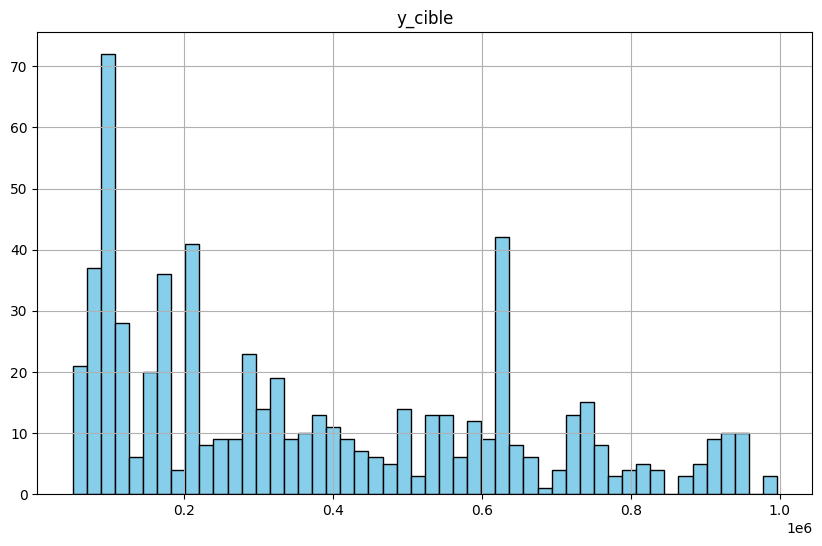

In [44]:
df_final_v2.hist(
    column='y_cible',
    bins=50,
    figsize=(10, 6),
    color='skyblue',
    edgecolor='black'
)

In [45]:
# Export et sauvegarde du jeu de données final
dataset_path = os.path.join(chemin_donnees, "DonneesPreparees", "dataset_final.csv")
df_final_v2.to_csv(dataset_path, index=False)

In [46]:
df_final_v2.shape

(640, 16)

In [47]:
df_final_v2['y_cible'].min()

np.float64(50240.0)

## Diagnostic des pertes 

In [48]:
# Diagnostic des pertes au niveau contrat

# On peut recalculer les pertes par contrat en agrégeant les garanties
# Mais cela reste pertinent pour l'analyse globale
# On refait une agrégation rapide pour le diagnostic
contrat_agg = df_final.groupby('police_clean').agg({
    'primnett': 'sum',  # prime totale acquise (somme des primes des garanties)
    'cout_total_sinistres': 'first'  # déjà agrégé au niveau contrat
}).reset_index()

contrat_agg['perte'] = contrat_agg['cout_total_sinistres'] - contrat_agg['primnett']
contrat_agg['flag_perte'] = contrat_agg['perte'] > 0
contrat_agg['ratio_SP'] = contrat_agg['cout_total_sinistres'] / contrat_agg['primnett'].replace(0, np.nan)

print("\n" + "="*60)
print("DIAGNOSTIC DES PERTES - Contrats terminés (2023-2025)")
print("="*60)
print(f"Nombre total de contrats analysés : {len(contrat_agg):,}")
print(f"Contrats avec sinistres : {contrat_agg[contrat_agg['cout_total_sinistres'] > 0].shape[0]:,}")
print(f"Contrats en perte : {contrat_agg['flag_perte'].sum():,} ({contrat_agg['flag_perte'].mean()*100:.2f}%)")
print("-"*60)
total_prime = contrat_agg['primnett'].sum()
total_cout = contrat_agg['cout_total_sinistres'].sum()
ratio_global = total_cout / total_prime if total_prime > 0 else 0
perte_totale = contrat_agg['perte'][contrat_agg['flag_perte']].sum()
print(f"Prime acquise totale (somme des primes des garanties) : {total_prime:,.0f} FCFA")
print(f"Coût total des sinistres : {total_cout:,.0f} FCFA")
print(f"Ratio S/P global : {ratio_global:.3f}")
print(f"Perte totale (contrats déficitaires) : {perte_totale:,.0f} FCFA")
print("="*60)



DIAGNOSTIC DES PERTES - Contrats terminés (2023-2025)
Nombre total de contrats analysés : 25,760
Contrats avec sinistres : 315
Contrats en perte : 197 (0.76%)
------------------------------------------------------------
Prime acquise totale (somme des primes des garanties) : 1,804,466,181 FCFA
Coût total des sinistres : 2,835,921,933 FCFA
Ratio S/P global : 1.572
Perte totale (contrats déficitaires) : 2,171,059,612 FCFA
